In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
housing = fetch_california_housing(as_frame=True)

df = housing.frame

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

Dataset loaded successfully.
Dataset shape: (20640, 9)


In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 20640
Number of columns: 9


In [4]:
print(df.dtypes)

MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object


In [5]:
missing_values = df.isnull().sum()

print("Missing values:")
print(missing_values)

Missing values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [6]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [7]:
print("Features:")
for column in df.columns:
    print(column)

Features:
MedInc
HouseAge
AveRooms
AveBedrms
Population
AveOccup
Latitude
Longitude
MedHouseVal


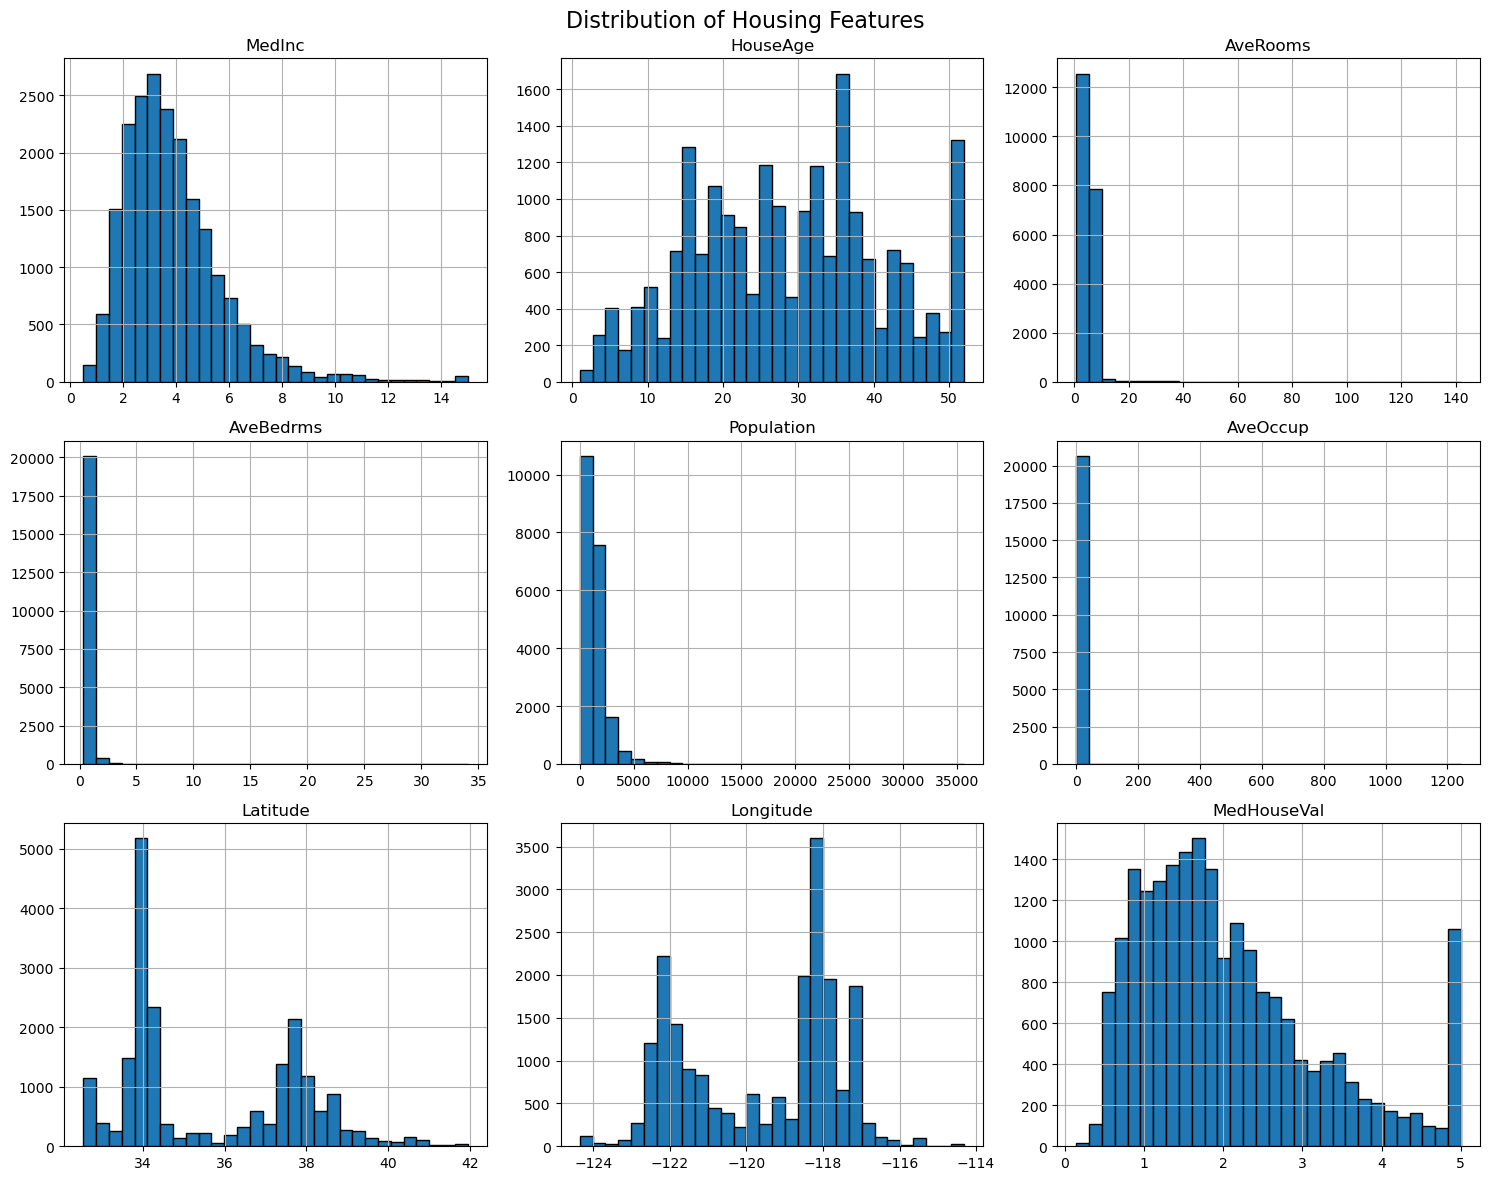

In [8]:
df.hist(
    figsize=(15, 12),
    bins=30,
    edgecolor="black"
)

plt.suptitle("Distribution of Housing Features", fontsize=16)
plt.tight_layout()
plt.show()

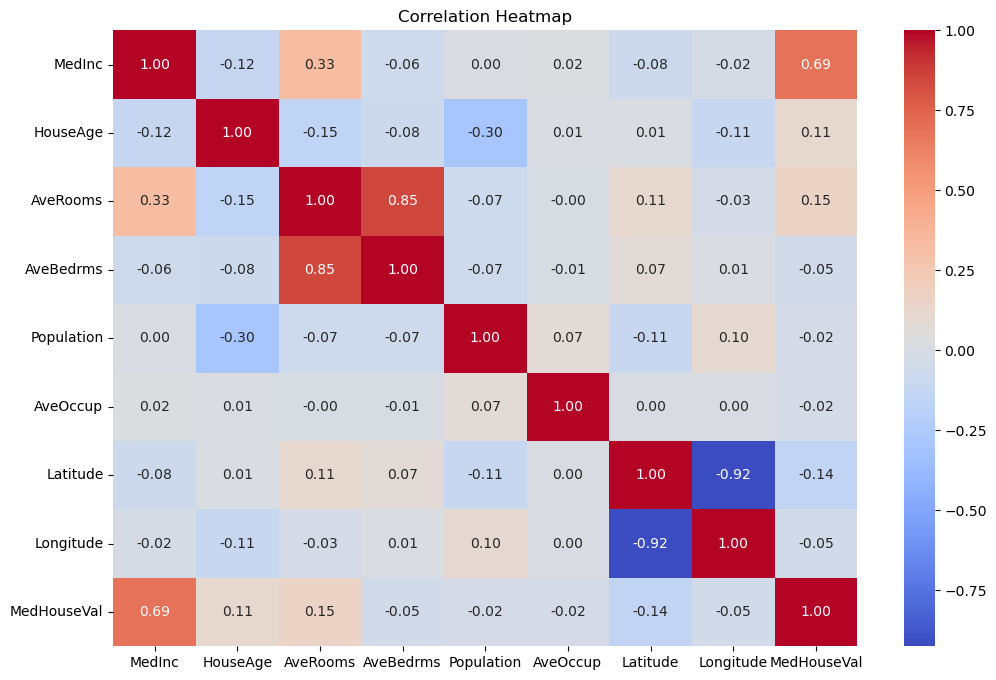

In [9]:
correlation_matrix = df.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [10]:
target = "MedHouseVal"

correlations = df.corr()[target].drop(target)

top_3_features = correlations.abs().sort_values(
    ascending=False
).head(3)

print("Top 3 features correlated with house price:")
print(top_3_features)
print("\nActual correlation values:")
print(correlations.loc[top_3_features.index])

Top 3 features correlated with house price:
MedInc      0.688075
AveRooms    0.151948
Latitude    0.144160
Name: MedHouseVal, dtype: float64

Actual correlation values:
MedInc      0.688075
AveRooms    0.151948
Latitude   -0.144160
Name: MedHouseVal, dtype: float64


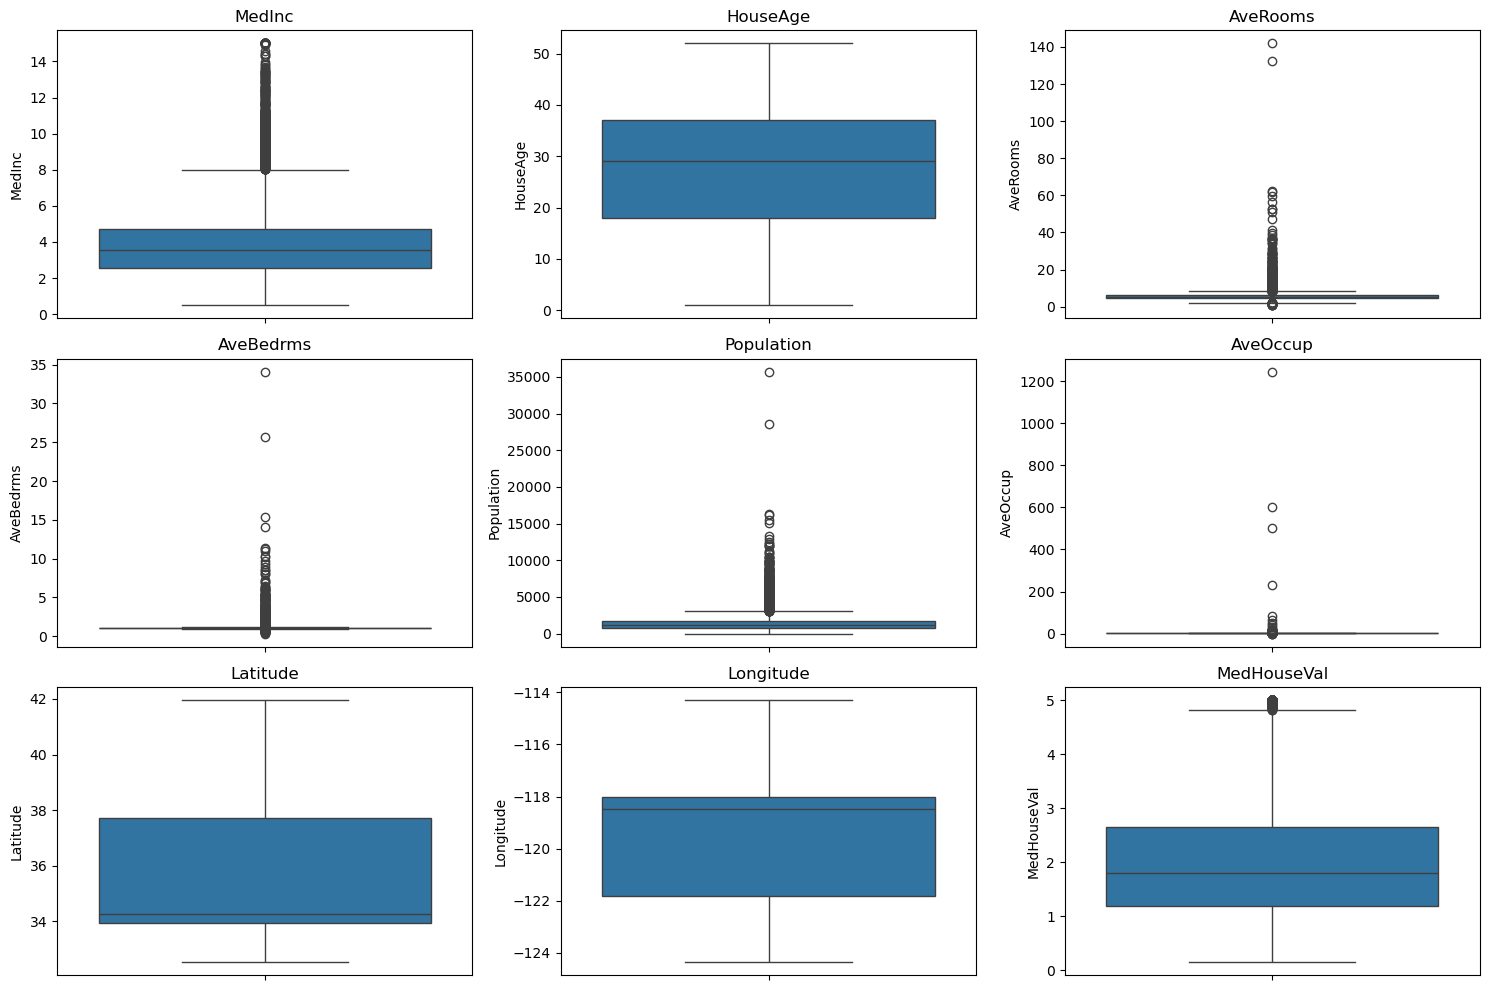

In [11]:
plt.figure(figsize=(15, 10))

for i, column in enumerate(df.columns, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[column])
    plt.title(column)

plt.tight_layout()
plt.show()

In [12]:
df["rooms_per_person"] = df["AveRooms"] / df["Population"]

df["rooms_per_person"] = df["rooms_per_person"].replace(
    [np.inf, -np.inf],
    np.nan
)

df["rooms_per_person"] = df["rooms_per_person"].fillna(
    df["rooms_per_person"].median()
)

print("rooms_per_person feature created.")

rooms_per_person feature created.


In [13]:
df["AgeCategory"] = pd.cut(
    df["HouseAge"],
    bins=[-np.inf, 20, 40, np.inf],
    labels=["Young", "Middle", "Old"]
)

print(df["AgeCategory"].value_counts())

AgeCategory
Middle    10469
Young      6293
Old        3878
Name: count, dtype: int64


In [14]:
df["AgeCategory_Code"] = df["AgeCategory"].map({
    "Young": 0,
    "Middle": 1,
    "Old": 2
})

print(df[["HouseAge", "AgeCategory", "AgeCategory_Code"]].head())

   HouseAge AgeCategory AgeCategory_Code
0      41.0         Old                2
1      21.0      Middle                1
2      52.0         Old                2
3      52.0         Old                2
4      52.0         Old                2


In [15]:
features = [
    "MedInc",
    "HouseAge",
    "AveRooms",
    "AveBedrms",
    "Population",
    "AveOccup",
    "Latitude",
    "Longitude",
    "rooms_per_person",
    "AgeCategory_Code"
]

X = df[features]
y = df["MedHouseVal"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (20640, 10)
Target: (20640,)


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 16512
Testing samples: 4128


In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [18]:
linear_model = LinearRegression()

linear_model.fit(
    X_train_scaled,
    y_train
)

linear_predictions = linear_model.predict(
    X_test_scaled
)

print("Linear Regression training completed.")

Linear Regression training completed.


In [19]:
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(
    X_train_scaled,
    y_train
)

ridge_predictions = ridge_model.predict(
    X_test_scaled
)

print("Ridge Regression training completed.")

Ridge Regression training completed.


In [20]:
lasso_model = Lasso(alpha=0.1)

lasso_model.fit(
    X_train_scaled,
    y_train
)

lasso_predictions = lasso_model.predict(
    X_test_scaled
)

print("Lasso Regression training completed.")

Lasso Regression training completed.


In [21]:
def evaluate_model(model_name, y_true, predictions):
    
    mae = mean_absolute_error(
        y_true,
        predictions
    )
    
    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            predictions
        )
    )
    
    r2 = r2_score(
        y_true,
        predictions
    )
    
    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    }

In [22]:
results = []

results.append(
    evaluate_model(
        "Linear Regression",
        y_test,
        linear_predictions
    )
)

results.append(
    evaluate_model(
        "Ridge Regression",
        y_test,
        ridge_predictions
    )
)

results.append(
    evaluate_model(
        "Lasso Regression",
        y_test,
        lasso_predictions
    )
)

results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.533296,0.745389,0.576006
1,Ridge Regression,0.533291,0.745368,0.576031
2,Lasso Regression,0.622201,0.824396,0.481361


In [23]:
print("MODEL PERFORMANCE")
print("=" * 70)

for _, row in results_df.iterrows():
    
    print(f"\n{row['Model']}")
    print(f"MAE      : {row['MAE']:.4f}")
    print(f"RMSE     : {row['RMSE']:.4f}")
    print(f"R² Score : {row['R2 Score']:.4f}")

MODEL PERFORMANCE

Linear Regression
MAE      : 0.5333
RMSE     : 0.7454
R² Score : 0.5760

Ridge Regression
MAE      : 0.5333
RMSE     : 0.7454
R² Score : 0.5760

Lasso Regression
MAE      : 0.6222
RMSE     : 0.8244
R² Score : 0.4814


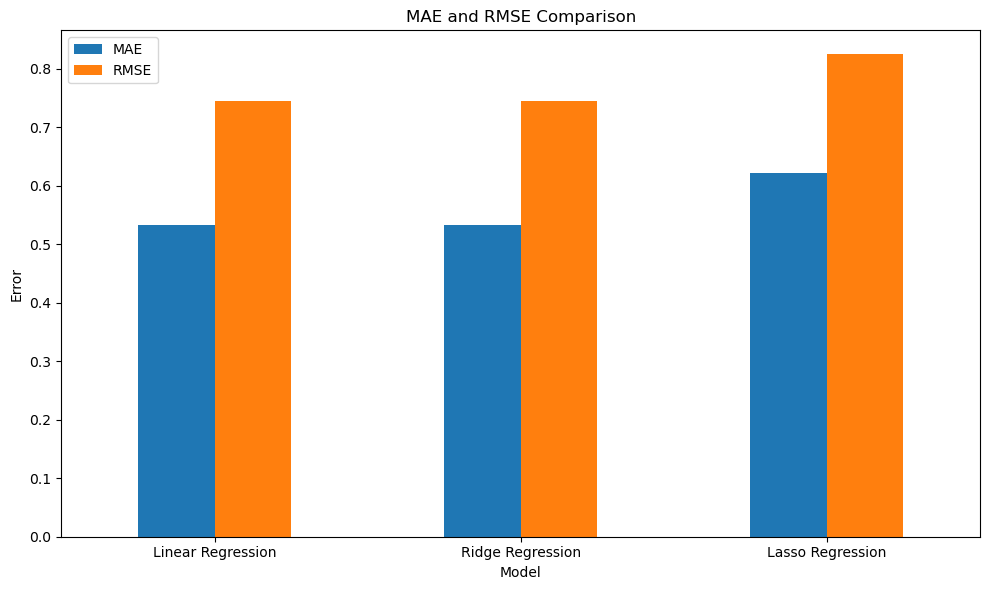

In [24]:
results_plot = results_df.set_index("Model")

results_plot[["MAE", "RMSE"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("MAE and RMSE Comparison")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

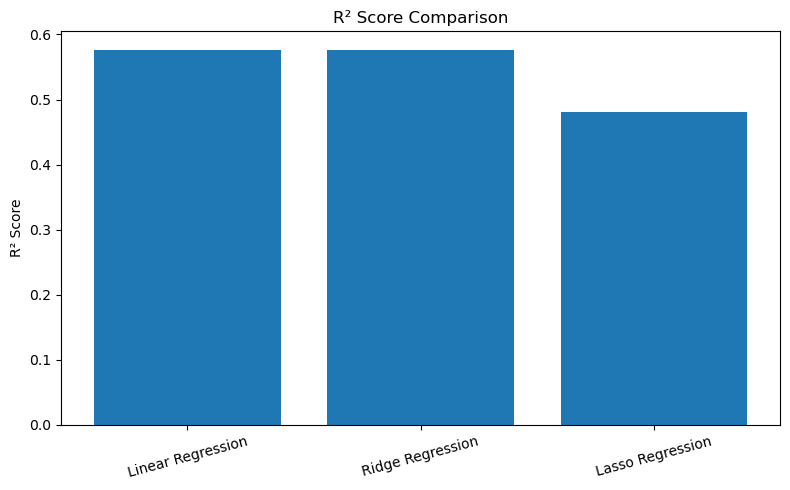

In [25]:
plt.figure(figsize=(8, 5))

plt.bar(
    results_df["Model"],
    results_df["R2 Score"]
)

plt.title("R² Score Comparison")
plt.ylabel("R² Score")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

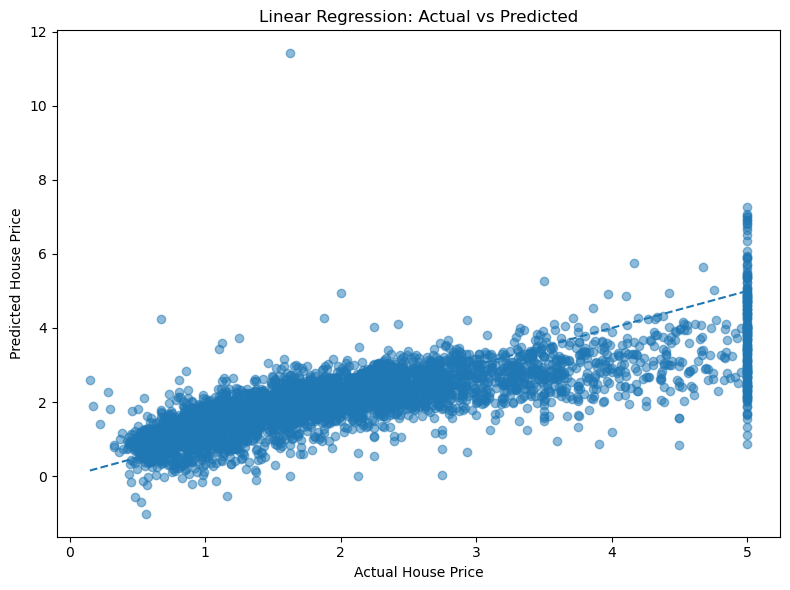

In [26]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    linear_predictions,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Linear Regression: Actual vs Predicted")

plt.tight_layout()
plt.show()

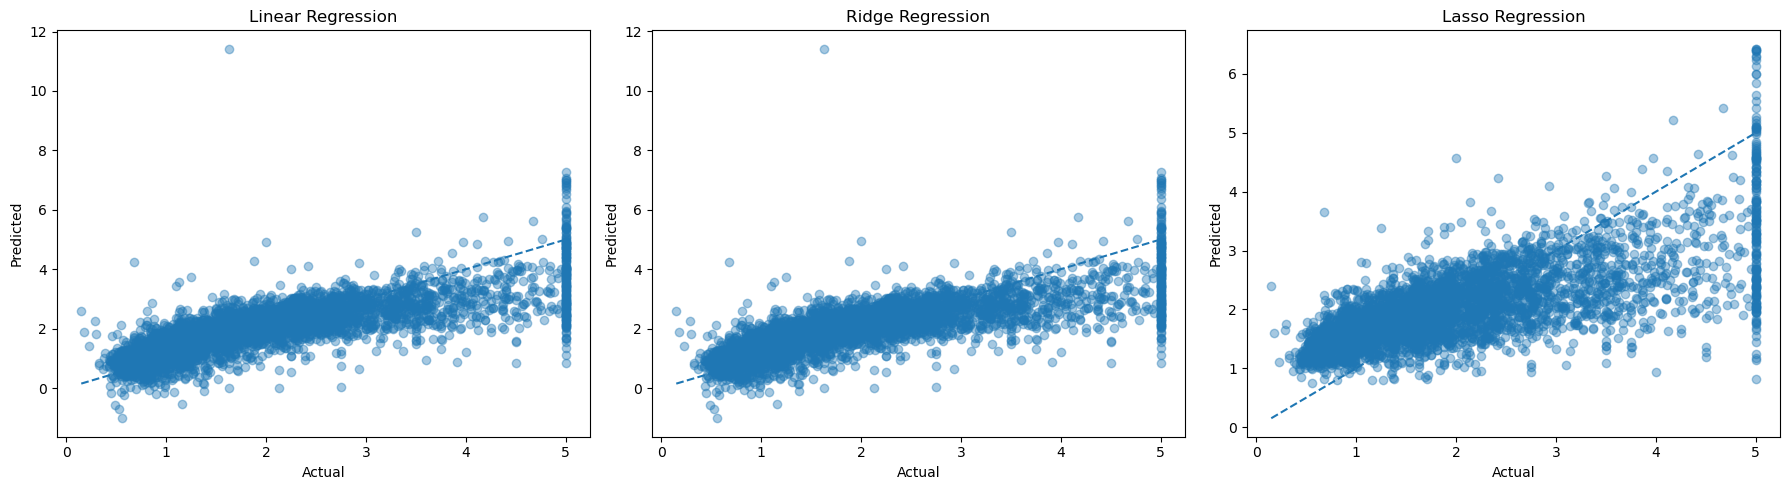

In [27]:
plt.figure(figsize=(18, 5))

models_predictions = [
    ("Linear Regression", linear_predictions),
    ("Ridge Regression", ridge_predictions),
    ("Lasso Regression", lasso_predictions)
]

for i, (name, predictions) in enumerate(
    models_predictions,
    1
):
    
    plt.subplot(1, 3, i)
    
    plt.scatter(
        y_test,
        predictions,
        alpha=0.4
    )
    
    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        linestyle="--"
    )
    
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(name)

plt.tight_layout()
plt.show()

In [28]:
best_model_name = results_df.loc[
    results_df["RMSE"].idxmin(),
    "Model"
]

print("Model with lowest RMSE:", best_model_name)

Model with lowest RMSE: Ridge Regression


In [29]:
prediction_dictionary = {
    "Linear Regression": linear_predictions,
    "Ridge Regression": ridge_predictions,
    "Lasso Regression": lasso_predictions
}

best_predictions = prediction_dictionary[
    best_model_name
]

print("Predictions selected for:", best_model_name)

Predictions selected for: Ridge Regression


In [30]:
residuals = y_test.values - best_predictions

print("Residual analysis completed.")
print("Mean residual:", residuals.mean())

Residual analysis completed.
Mean residual: 0.0035621398273322264


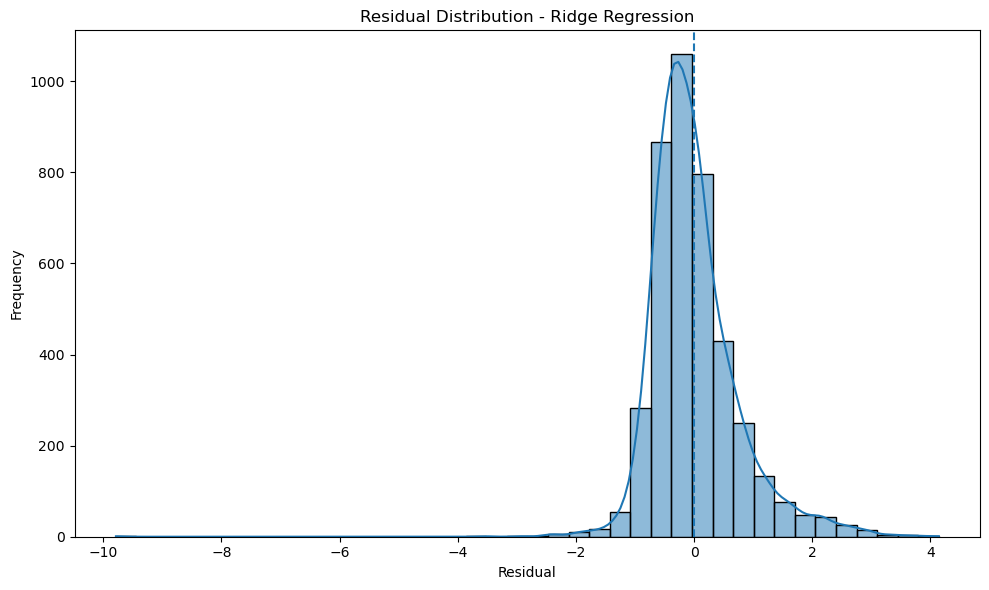

In [31]:
plt.figure(figsize=(10, 6))

sns.histplot(
    residuals,
    bins=40,
    kde=True
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title(
    f"Residual Distribution - {best_model_name}"
)

plt.tight_layout()
plt.show()

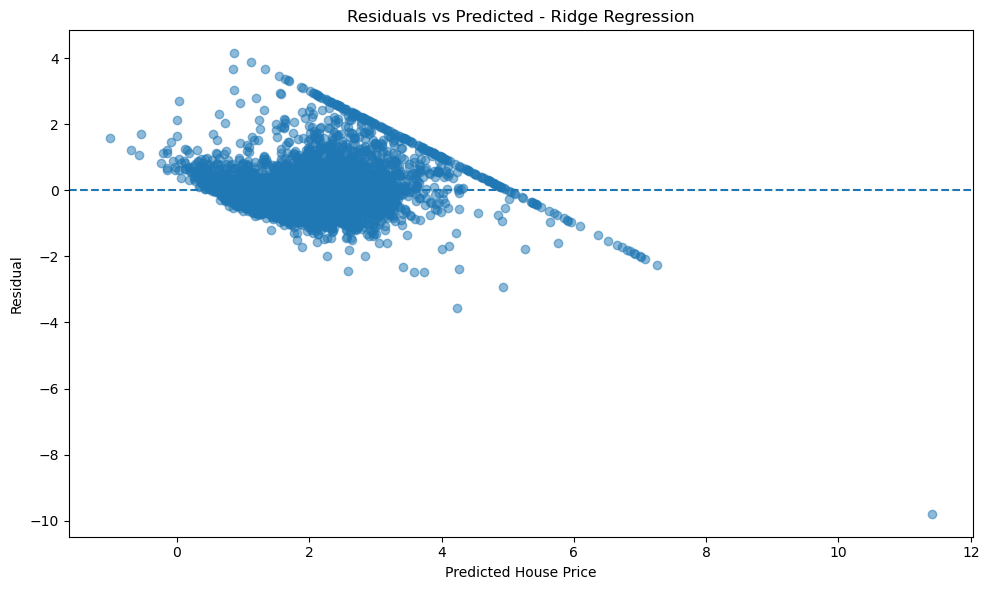

In [32]:
plt.figure(figsize=(10, 6))

plt.scatter(
    best_predictions,
    residuals,
    alpha=0.5
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted House Price")
plt.ylabel("Residual")
plt.title(
    f"Residuals vs Predicted - {best_model_name}"
)

plt.tight_layout()
plt.show()

In [33]:
analysis_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": best_predictions,
    "Residual": residuals
})

most_under_predicted = analysis_df.sort_values(
    "Residual",
    ascending=False
).head(10)

print("10 Most Under-Predicted Houses")
print(most_under_predicted)

10 Most Under-Predicted Houses
       Actual  Predicted  Residual
1649  5.00001   0.857741  4.142269
1140  5.00001   1.121965  3.878045
872   5.00001   1.335256  3.664754
3710  4.50000   0.842527  3.657473
1865  5.00001   1.544688  3.455322
1138  5.00001   1.639048  3.360962
3693  5.00001   1.676327  3.323683
3761  5.00001   1.695911  3.304099
1655  5.00001   1.868784  3.131226
429   5.00001   1.902466  3.097544


In [34]:
most_over_predicted = analysis_df.sort_values(
    "Residual",
    ascending=True
).head(10)

print("10 Most Over-Predicted Houses")
print(most_over_predicted)

10 Most Over-Predicted Houses
       Actual  Predicted  Residual
3722  1.62500  11.411620 -9.786620
1250  0.67500   4.229768 -3.554768
112   2.00000   4.932115 -2.932115
285   1.25000   3.738122 -2.488122
2047  1.12500   3.584441 -2.459441
3029  0.14999   2.582965 -2.432975
2558  1.87500   4.270861 -2.395861
3246  1.10000   3.424657 -2.324657
2904  5.00001   7.257171 -2.257161
2051  5.00001   7.072762 -2.072752


In [35]:
model_package = {
    "model": prediction_dictionary,
    "scaler": scaler,
    "features": features,
    "selected_model": best_model_name
}
trained_models = {
    "Linear Regression": linear_model,
    "Ridge Regression": ridge_model,
    "Lasso Regression": lasso_model
}

best_model = trained_models[best_model_name]

joblib.dump(
    {
        "model": best_model,
        "scaler": scaler,
        "features": features,
        "model_name": best_model_name
    },
    "house_price_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [36]:
loaded_package = joblib.load(
    "house_price_model.pkl"
)

loaded_model = loaded_package["model"]
loaded_scaler = loaded_package["scaler"]
loaded_features = loaded_package["features"]
loaded_model_name = loaded_package["model_name"]

print("Model loaded successfully.")
print("Loaded model:", loaded_model_name)

Model loaded successfully.
Loaded model: Ridge Regression


In [37]:
custom_house = pd.DataFrame({
    "MedInc": [5.0],
    "HouseAge": [20],
    "AveRooms": [5.5],
    "AveBedrms": [1.0],
    "Population": [1000],
    "AveOccup": [3.0],
    "Latitude": [34.05],
    "Longitude": [-118.25],
})

In [38]:
custom_house["rooms_per_person"] = (
    custom_house["AveRooms"] /
    custom_house["Population"]
)

custom_house["AgeCategory_Code"] = pd.cut(
    custom_house["HouseAge"],
    bins=[-np.inf, 20, 40, np.inf],
    labels=["Young", "Middle", "Old"]
).map({
    "Young": 0,
    "Middle": 1,
    "Old": 2
})

custom_house = custom_house[loaded_features]

print(custom_house)

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0     5.0        20       5.5        1.0        1000       3.0     34.05   

   Longitude  rooms_per_person AgeCategory_Code  
0    -118.25            0.0055                0  


In [39]:
custom_scaled = loaded_scaler.transform(
    custom_house
)

print("Custom house data scaled.")

Custom house data scaled.


In [40]:
predicted_price = loaded_model.predict(
    custom_scaled
)[0]

print(
    f"Predicted House Value: ${predicted_price * 100000:,.2f}"
)

Predicted House Value: $248,549.07


In [41]:
print("=" * 60)
print("HOUSE PRICE PREDICTION MODEL SUMMARY")
print("=" * 60)

print("\nSelected Model:", best_model_name)

selected_result = results_df[
    results_df["Model"] == best_model_name
].iloc[0]

print(f"MAE      : {selected_result['MAE']:.4f}")
print(f"RMSE     : {selected_result['RMSE']:.4f}")
print(f"R² Score : {selected_result['R2 Score']:.4f}")

print(
    f"\nPredicted value for custom house: "
    f"${predicted_price * 100000:,.2f}"
)

HOUSE PRICE PREDICTION MODEL SUMMARY

Selected Model: Ridge Regression
MAE      : 0.5333
RMSE     : 0.7454
R² Score : 0.5760

Predicted value for custom house: $248,549.07
